In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
def housing_data_reader(filename='./data/housing_price.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['MEDV'],axis = 1)
    y =  data['MEDV']
    return X, y

def fetal_health_data_reader(filename='./data/fetal_health.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['fetal_health'],axis = 1)
    y =  data['fetal_health']
    return X, y

def heart_disease_data_reader(filename='./data/diabetes_binary_health_indicators_BRFSS2015.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['Diabetes_binary', 'Education'],axis = 1)
    y =  data['Diabetes_binary']
    return X, y

def h1n1_data_reader(filename='./data/process_data.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['h1n1_vaccine','respondent_id','seasonal_vaccine'],axis = 1)
    y =  data['h1n1_vaccine']
    return X, y

### Define the characteristic function

In [2]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import r2_score
# define the characteristic function
def classification_kpi(G,S):
    """_summary_

    Args:
        G (nx.Graph): _description_
        S (list): list of nodes (list of columns)
    """
    cols = list(S)
    if len(cols) == 0:
        return 0
    else:
        X_train, X_test, y_train, y_test = train_test_split(X_vac_mst[cols], y_vac_mst, test_size=0.2, random_state=7)
        lgb_model = lgb.LGBMRegressor(learning_rate=0.05, verbosity=-1)

        lgb_model.fit(X_train,y_train)
        lgb_pred = lgb_model.predict(X_test)
        r2 = r2_score(y_test, lgb_pred)
        return r2

In [3]:
# ===== Fig.8/9-style evaluation: R^2 removal curves =====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.dummy import DummyRegressor

# --- 1) Value function v(S): R^2 with only features S, using K-Fold CV ---
def v_r2_cv(model_factory, X_df, y, S, n_splits=5, random_state=42):
    """
    Returns K-Fold CV R^2 using ONLY columns in S.
    If S is empty, returns baseline (DummyRegressor) R^2.
    """
    if isinstance(S, (set, tuple, list, np.ndarray)):
        S = list(S)
    elif S is None:
        S = []
    if len(S) == 0:
        # baseline: predict mean; R^2 will be ~0 by definition
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        preds, trues = [], []
        for tr, va in kf.split(X_df):
            y_tr, y_va = y[tr], y[va]
            # Dummy regressor predicts mean of train
            d = DummyRegressor(strategy="mean").fit(np.zeros((len(tr), 1)), y_tr)
            p = d.predict(np.zeros((len(va), 1)))
            preds.append(p); trues.append(y_va)
        preds = np.concatenate(preds); trues = np.concatenate(trues)
        return float(r2_score(trues, preds))

    Xs = X_df[S].values
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    preds, trues = [], []
    for tr, va in kf.split(Xs):
        m = model_factory()
        m.fit(Xs[tr], y[tr])
        p = m.predict(Xs[va])
        preds.append(p); trues.append(y[va])
    preds = np.concatenate(preds); trues = np.concatenate(trues)
    return float(r2_score(trues, preds))


# --- 2) Build a removal curve for one ranking ---
def removal_curve(v_fn, all_features, ranking, step=1):
    """
    v_fn(S): callable returning a score (higher=better) for subset S (list of feature names).
    ranking: list of features from most->least important (drop in this order).
    step: drop this many per step (e.g., 1 or 2) to speed up.
    Returns: list of (num_removed, score)
    """
    kept = list(all_features)
    curve = [(0, v_fn(kept))]
    for r in range(step, len(all_features)+1, step):
        to_drop = set(ranking[:r])
        kept = [f for f in all_features if f not in to_drop]
        curve.append((r, v_fn(kept)))
    if curve[-1][0] != len(all_features):
        curve.append((len(all_features), v_fn([])))
    return curve


# --- 3) Paper’s slope score S (alpha=0.8 by default; higher = better) ---
def slope_score_S(curve, alpha=0.8):
    """
    Distribute each step's drop equally across 'step' removed features,
    then weight earlier drops more by alpha^i (i=0..n-1).
    """
    drops = []
    for k in range(1, len(curve)):
        r_prev, s_prev = curve[k-1]
        r_cur,  s_cur  = curve[k]
        step = r_cur - r_prev
        delta = max(0.0, s_prev - s_cur)
        per = delta / step if step > 0 else 0.0
        drops.extend([per]*step)
    if not drops:
        return 0.0
    weights = np.array([alpha**i for i in range(len(drops))], dtype=float)
    return float(np.sum(weights * np.array(drops)))


# --- 4) Plot multiple curves (Fig.8/9 style) ---
def plot_removal_curves(curves_dict, title="Feature Removal – R² vs #Removed", xlabel="# features removed", ylabel="R²"):
    plt.figure(figsize=(7.5, 5.0))
    for name, curve in curves_dict.items():
        xs, ys = zip(*curve)
        plt.plot(xs, ys, marker='o', linewidth=2, label=name)
    plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout()


In [113]:
def r2_gain(G, S):
    # train/eval with only features S using K-Fold CV and return R^2 (higher=better)
    return v_r2_cv(X_vac_mst[cols], y_vac_mst, S, n_splits=5, random_state=42)  # reuse the CV fn you used to plot

In [4]:
import seaborn as sns
import networkx as nx

# plot the networkx graph for W and W_new
def plot_graph(W, file_name=None):
    """_summary_

    Args:
        W (pd.DataFrame): weight matrix
    """
    G = nx.Graph(W)
    plt.figure(figsize=(5, 5))
    nx.draw_shell(G, with_labels=True)
    if file_name is not None:
        plt.savefig(file_name, format='eps', dpi=300)
    plt.show()

### Import shapG, some necessary libraries and explain the model

In [5]:
# import shapG and necessary libraries
import networkx as nx
import seaborn as sns
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import pearsonr,kendalltau,spearmanr
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('.'), '..')))
import shapG.shapley as shapley
import shapG.plot as shapGplot
from shapG.utils import corr_generator, create_minimal_edge_graph, matrix_generator, kl, kl_mi_matrix


In [6]:
from shapG.lasso import *
from shapG.mst import *
from shapG.mst_graph import *

In [87]:
# explain the model
X_vac_org, y_vac_org = h1n1_data_reader(filename='./data/process_data.csv')
W_vac_org = matrix_generator(X_vac_org, pearsonr)
A_vac_org, W_new_vac_org = create_minimal_edge_graph(W_vac_org, reverse=True, version='v3', verbose=True)
G_vac_org = nx.Graph(A_vac_org)
shapley_value_vac_org = shapley.shapG(G_vac_org, m=3, f=classification_kpi, approximate_by_ratio=True)
fig_org, ax_org = shapGplot(shapley_value_vac_org, top_n=30, show_plot=False)
ax_org.set_xlabel("Feature importance", fontsize=14)
ax_org.set_ylabel("Features", fontsize=14)
ax_org.spines['top'].set_visible(False)
ax_org.spines['right'].set_visible(False)
ax_org.set_title('Top 30 influential features', fontsize=16)
plt.show()

v3 terminating at weight: 0.032625581990010755


KeyboardInterrupt: 

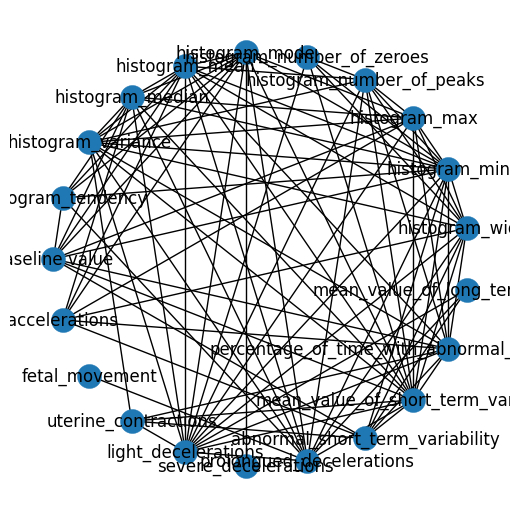

In [45]:
plot_graph(W_new_vac_org, file_name=None)

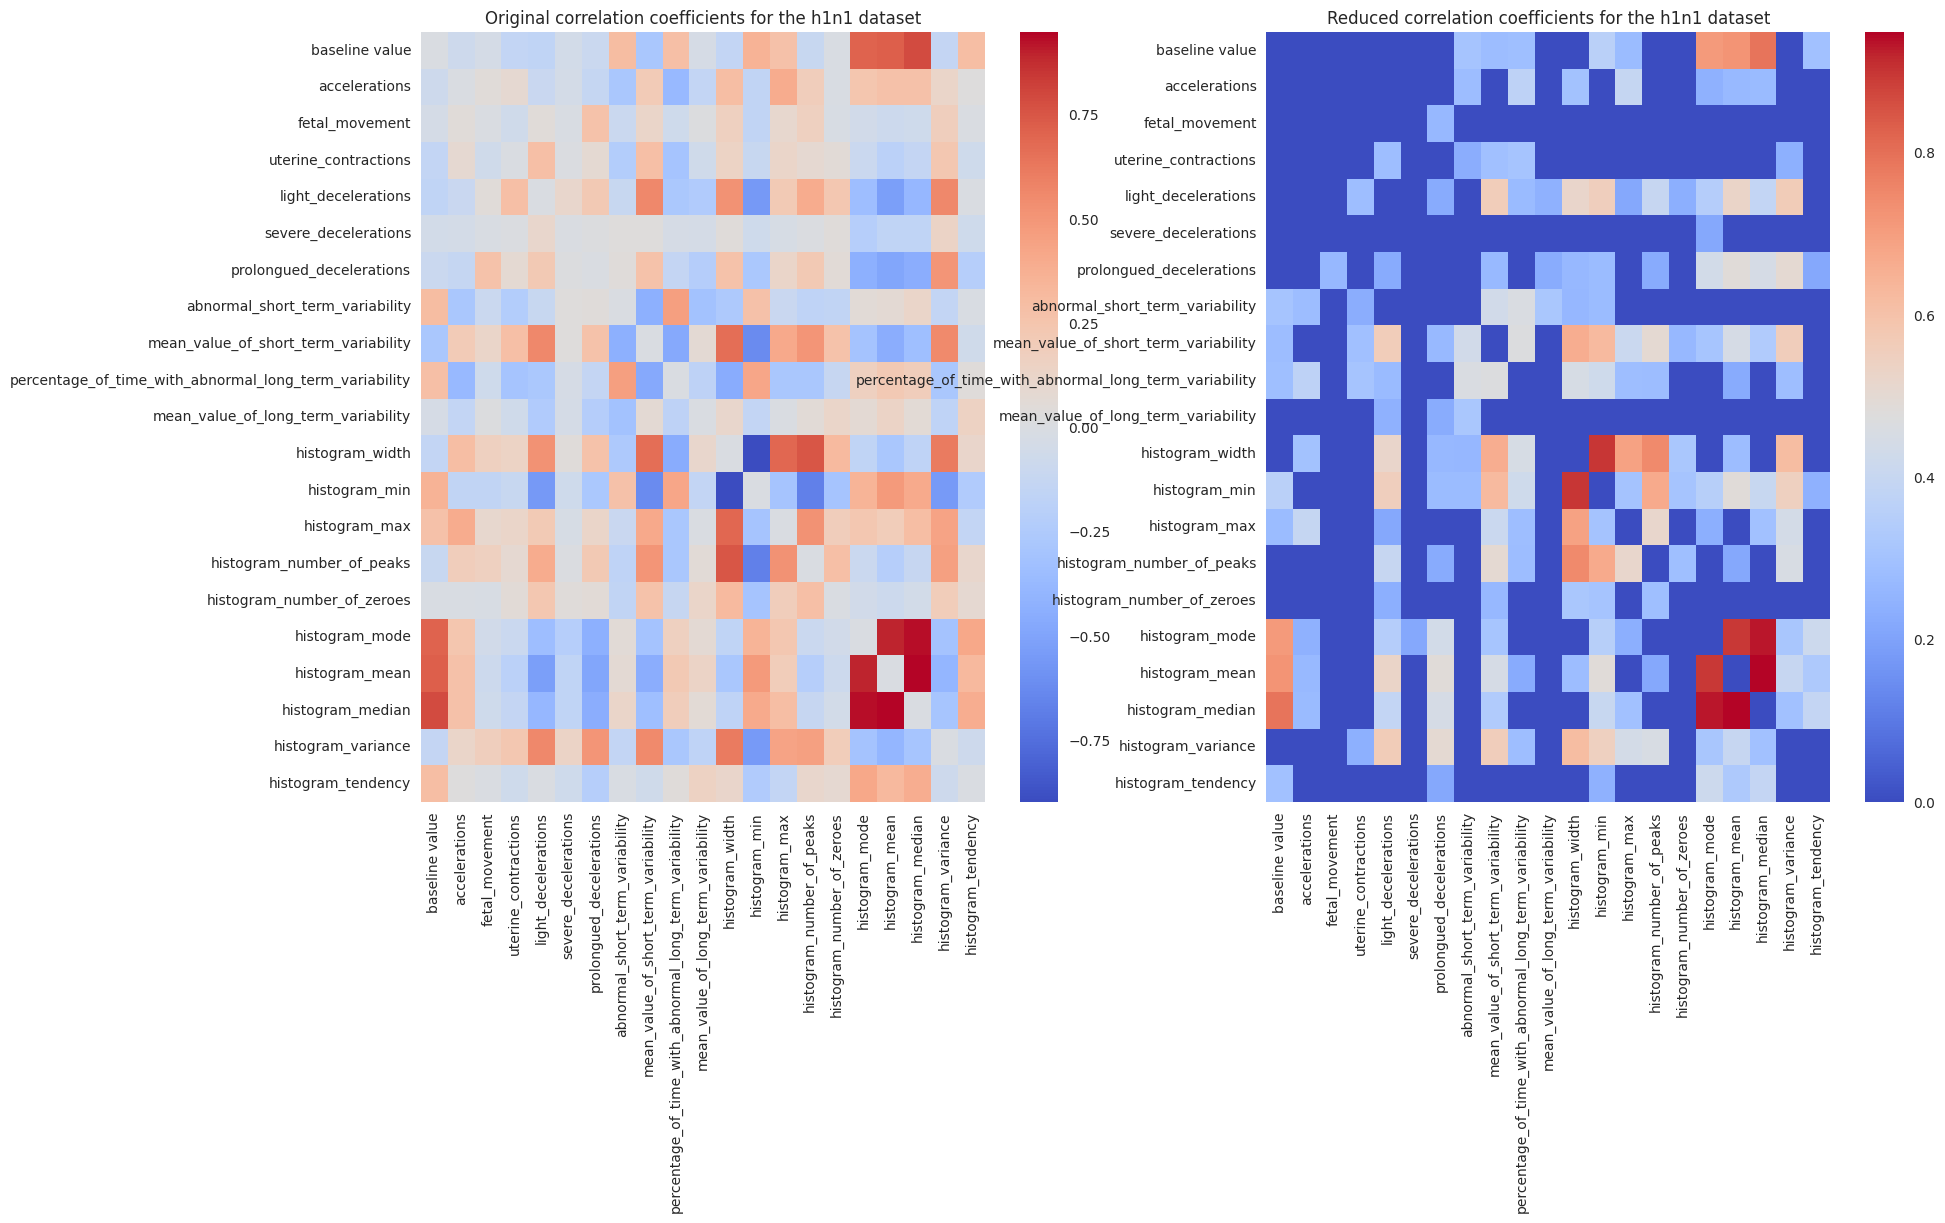

In [46]:
# create two heatmaps for W and W_new
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
sns.heatmap(W_vac_org, annot=False, cmap='coolwarm', cbar=True)
plt.title('Original correlation coefficients for the h1n1 dataset')
plt.subplot(1, 2, 2)
sns.heatmap(W_new_vac_org, annot=False, cmap='coolwarm', cbar=True)
plt.title('Reduced correlation coefficients for the h1n1 dataset')
# plt.savefig('housing-heatmap.eps', format='eps', dpi=300)

plt.show()

In [34]:
from sklearn.covariance import GraphicalLasso, graphical_lasso

In [ ]:
# explain the model
X_vac, y_vac = h1n1_data_reader('./data/process_data.csv')
# W_hd = matrix_generator(X_hd, method="stars_glasso")

W_vac = matrix_generator_lasso(X_vac, method="stars_glasso",
                            # B=80, subsample_frac=0.9, beta=0.10,              # more tolerant stability
                            alphas=None,                                      # we'll patch to extend grid
                            nonparanormal=True,                                # try False as an A/B if needed
                            # StARS: more precise stability estimates
                            B=200,                 # more subsamples
                            subsample_frac=0.95,   # larger subsamples
                            beta=0.03,             # stricter stability

                            # Solver: tighter & longer
                            max_iter=500,          # more CD iterations
                            )
W_vac, W_vac = stars_glasso_corr_generator_lasso(X_vac, return_probs=True)  # with stability probs
A_vac, W_new_vac = create_minimal_edge_graph(W_vac, reverse=True, version='v3')

# A_hd, W_new_hd = create_minimal_edge_graph(W_hd, reverse=True, version='v3')
G_vac = nx.Graph(A_vac)
shapley_value_vac = shapley.shapG(G_vac, m=3, f=classification_kpi, approximate_by_ratio=False)
fig, ax = shapGplot(shapley_value_vac, top_n=30, show_plot=False)
ax.set_xlabel("Feature importance", fontsize=14)
ax.set_ylabel("Features", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Top 30 influential features', fontsize=16)
plt.show()

KeyboardInterrupt: 

In [8]:
plot_graph(W_new_vac, file_name=None)

NameError: name 'W_new_vac' is not defined

In [114]:
# explain the model
X_vac_mst, y_vac_mst = h1n1_data_reader(filename='./data/process_data.csv')
W_vac_mst = matrix_generator_mst(X_vac_mst, method=spearmanr)
A_vac_mst, W_new_vac_mst = create_minimal_edge_graph_mst(W_vac_mst, version='mst', verbose=True)
G_vac_mst = nx.Graph(A_vac_mst)
shapley_value_vac_mst = shapley.shapG(
    G_vac_mst,
    m=3,
    # f=classification_kpi,
    f=r2_gain,
    approximate_by_ratio=True,
    scale=True,
    verbose=True
)
fig_mst, ax_mst = shapGplot(shapley_value_vac_mst, top_n=30, show_plot=False)
ax_mst.set_xlabel("Feature importance", fontsize=14)
ax_mst.set_ylabel("Features", fontsize=14)
ax_mst.spines['top'].set_visible(False)
ax_mst.spines['right'].set_visible(False)
ax_mst.set_title('Top 30 influential features', fontsize=16)
plt.show()

[mst] edges selected: 34


NameError: name 'cols' is not defined

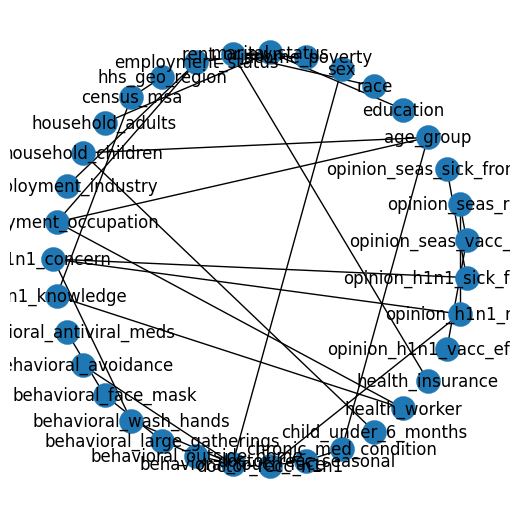

In [95]:
plot_graph(W_new_vac_mst, file_name=None)

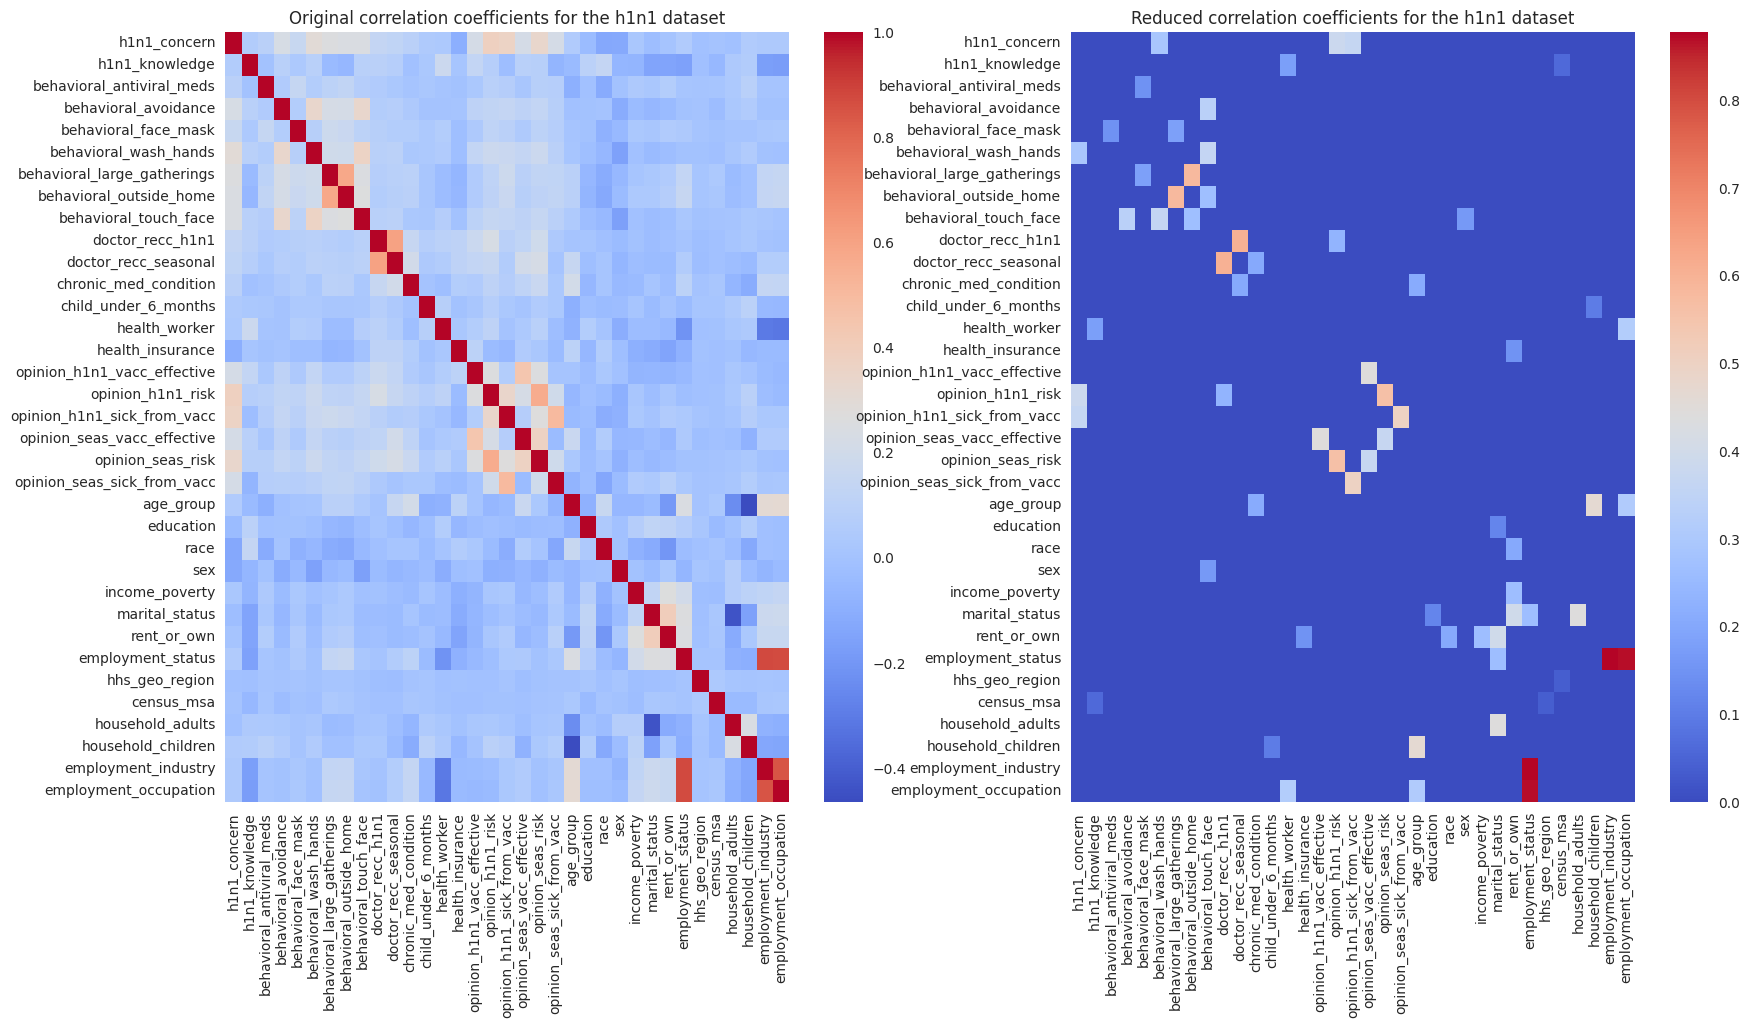

In [32]:
# create two heatmaps for W and W_new
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
sns.heatmap(W_vac_mst, annot=False, cmap='coolwarm', cbar=True)
plt.title('Original correlation coefficients for the h1n1 dataset')
plt.subplot(1, 2, 2)
sns.heatmap(W_new_vac_mst, annot=False, cmap='coolwarm', cbar=True)
plt.title('Reduced correlation coefficients for the h1n1 dataset')
# plt.savefig('housing-heatmap.eps', format='eps', dpi=300)

plt.show()

In [96]:
import xgboost

import shap

# train XGBoost model
X_vac_shap, y_vac_shap = h1n1_data_reader(filename='./data/process_data.csv')
model = lgb.LGBMRegressor(learning_rate=0.05, verbosity=-1).fit(X_vac_shap, y_vac_shap)
# compute SHAP values
explainer = shap.Explainer(model, X_vac_shap)
shap_values = explainer(X_vac_shap)


 99%|===================| 26432/26707 [01:32<00:00]        

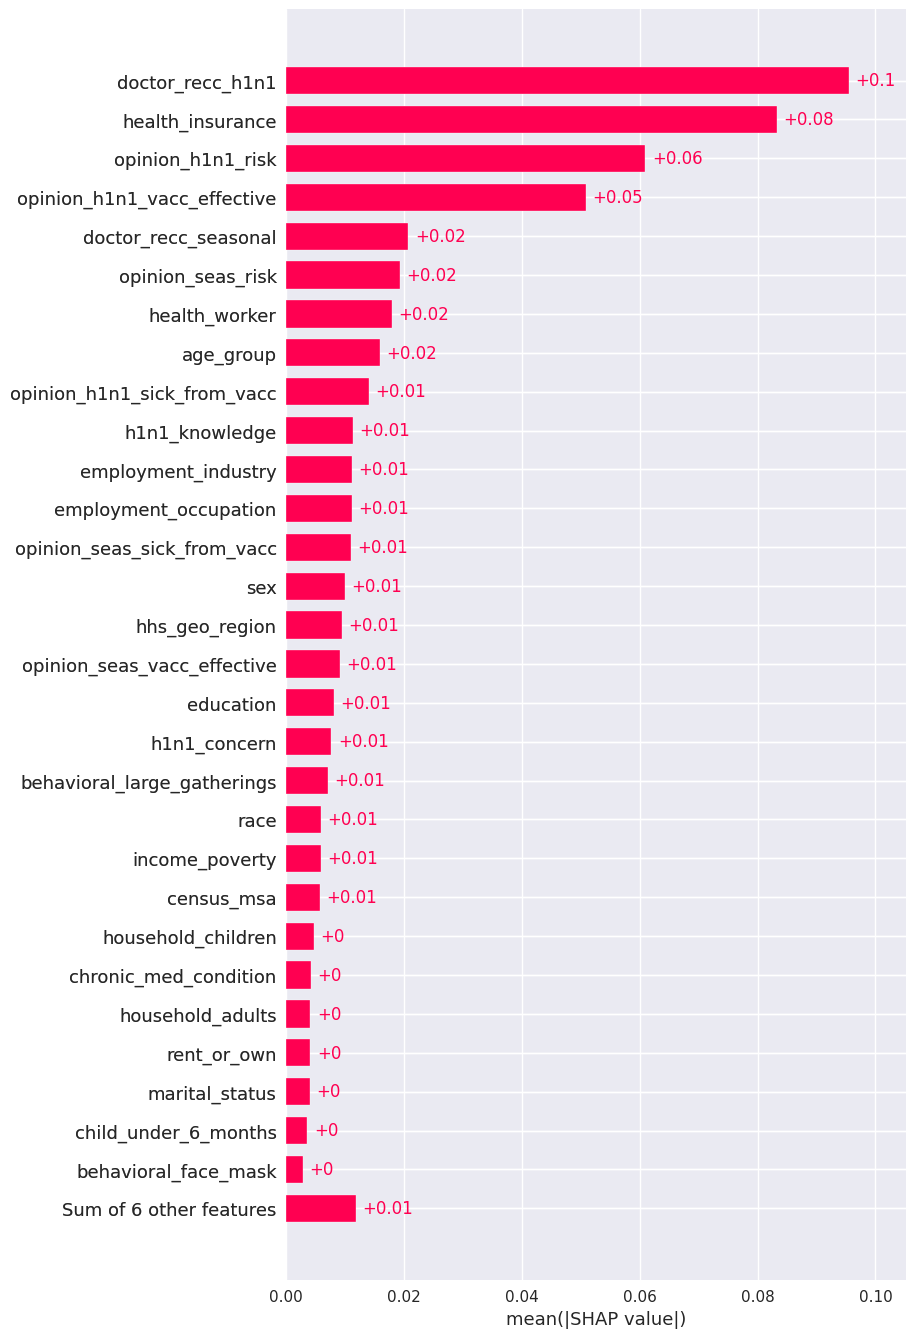

In [39]:
shap.plots.bar(shap_values, max_display=30)

In [70]:
import time
import numpy as np

def to_ranking(phi: dict):
    """Return features sorted from most to least important."""
    return sorted(phi, key=phi.get, reverse=True)

def removal_curve(v_fn, all_features, ranking, step=1):
    """
    v_fn(S): returns model metric (higher=better) using ONLY features in S.
    all_features: list of all feature names
    ranking: list of features from most->least important (for removal order)
    step: drop this many each step to speed up
    Returns: list of (num_removed, score)
    """
    kept = list(all_features)
    curve = [(0, v_fn(kept))]
    for r in range(step, len(all_features)+1, step):
        drop = set(ranking[:r])
        kept = [f for f in all_features if f not in drop]
        curve.append((r, v_fn(kept)))
    # ensure last point (all removed)
    if len(curve) == 0 or curve[-1][0] != len(all_features):
        curve.append((len(all_features), v_fn([])))
    return curve

def slope_score_S(curve, alpha=0.8):
    """
    Paper's weighted 'slope score' S (higher is better).
    Let Δ_i be the drop in metric after removing the i-th feature in ranking.
    We rebuild Δ_i from the curve.
    """
    # Expand to single-step drops to compute Δ_i
    # curve is [(0, score0), (r1, s1), (r2, s2), ...]
    # Interpolate per-feature drops across steps
    drops = []
    for k in range(1, len(curve)):
        r_prev, s_prev = curve[k-1]
        r_cur, s_cur   = curve[k]
        step = r_cur - r_prev
        delta = max(0.0, s_prev - s_cur)
        # spread equally across 'step' removed features (paper uses total decreases with weights)
        per = delta / step if step > 0 else 0.0
        drops.extend([per] * step)

    n = len(drops)
    if n == 0:
        return 0.0
    # Weighted sum: sum_{i=1..n} α^{i-1} * Δ_i
    weights = np.array([alpha**i for i in range(n)], dtype=float)  # i=0..n-1
    S = float((weights * np.array(drops)).sum())
    return S

def timed_call(fn, *args, **kwargs):
    t0 = time.time()
    out = fn(*args, **kwargs)
    return out, time.time() - t0

In [71]:
# Example wrapper using your existing training/eval (sklearn-compatible)
# v_fn should return a score where higher is better (e.g., F1 or accuracy).
def v_fn(S):
    # S may be list of names; if empty, return baseline (e.g., majority-class F1≈0)
    return classification_kpi(S)  # <-- implement to accept a feature subset and return metric

In [74]:
# You already computed:
# shapley_value_vac_mst = shapley.shapG(G_vac_mst, m=7, f=classification_kpi, approximate_by_ratio=True)

# Convert to dict {feature_name: value}
feature_names = list(X_vac_mst.columns)

if isinstance(shapley_value_vac_mst, dict):
    phi_mst = shapley_value_vac_mst
else:
    import numpy as np
    vals = np.asarray(shapley_value_vac_mst).reshape(-1)
    assert len(vals) == len(feature_names), "ShapG output length must match #features"
    phi_mst = {f: float(v) for f, v in zip(feature_names, vals)}

In [75]:
import numpy as np
import shap

# Your code:
# X_vac_shap, y_vac_shap = h1n1_data_reader('./data/process_data.csv')
# model = lgb.LGBMRegressor(learning_rate=0.2, verbosity=-1).fit(X_vac_shap, y_vac_shap)
# explainer = shap.Explainer(model, X_vac_shap)      # or shap.TreeExplainer(model) for tree models
# shap_values = explainer(X_vac_shap)                # shap.Explanation

# Get feature names consistent with your DataFrame
feature_names_shap = list(X_vac_shap.columns)

# Mean absolute SHAP across rows -> one number per feature
vals = np.mean(np.abs(shap_values.values), axis=0)   # shape: (n_features,)

phi_shap = {f: float(v) for f, v in zip(feature_names_shap, vals)}


In [76]:
def normalize_to_gain(phi: dict, v_full: float, v_empty: float):
    gain = v_full - v_empty
    s = sum(phi.values())
    if s == 0:
        return phi.copy()
    return {f: (v * gain / s) for f, v in phi.items()}

# Reuse your characteristic function for a consistent gain:
# v(S) must return a score to MAXIMIZE (e.g., AUCPR, F1, R^2). For classification_kpi, ensure higher=better.
all_feats = list(X_vac_mst.columns)
v_empty = classification_kpi([])          # metric with no features (baseline)
v_full  = classification_kpi(all_feats)   # metric with all features

phi_mst_n  = normalize_to_gain(phi_mst,  v_full, v_empty)
phi_shap_n = normalize_to_gain(phi_shap, v_full, v_empty)

TypeError: classification_kpi() missing 1 required positional argument: 'S'

In [77]:
# 1) Prepare rankings (most -> least important)
rank_mst  = to_ranking(phi_mst)
rank_shap = to_ranking(phi_shap)

# 2) Build removal curves (use a slightly larger step to speed up, e.g., drop 1 or 2 at a time)
all_features = list(shapley_value_vac_mst.keys())
curve_mst  = removal_curve(v_fn, all_features, rank_mst,  step=1)
curve_shap = removal_curve(v_fn, all_features, rank_shap, step=1)

# 3) Compute slope score S with alpha=0.8 (paper setting)
S_mst  = slope_score_S(curve_mst,  alpha=0.8)
S_shap = slope_score_S(curve_shap, alpha=0.8)

# 4) Time each explainer (paper’s runtime metric)
# (A) time to compute phi_mst (your ShapG call)
# (B) time to compute phi_shap (SHAP Explainer call)
# Save/plot (time, 1/S) points to mimic Figure 5
print({"S_mst": S_mst, "S_shap": S_shap})

TypeError: classification_kpi() missing 1 required positional argument: 'S'

In [100]:
# explain the model
X_vac_mst_graph, y_vac_mst_graph = h1n1_data_reader('./data/process_data.csv')
W_vac_mst_graph = matrix_generator_mst(X_vac_mst_graph, pearsonr)
A_vac_mst_graph, W_new_vac_mst_graph = create_minimal_edge_graph_mst_graph(
    W_vac_mst_graph,
    version='mst_dense',
    pct_tau=1,           # lower (e.g., 0.90) -> denser
    knn_k=8,                # raise to 10 if you still want more magnitude
    avg_degree_floor=2.0,   # try 3.4 if still small; 3.0 if too dense
    min_degree_floor=2,
    triangle_closing=True,
    triangle_budget_per_node=3,
    verbose=True
)
G_vac_mst_graph = nx.Graph(A_vac_mst_graph)
shapley_value_vac_mst_graph = shapley.shapG(
    G_vac_mst_graph,
    m=3,
    f=classification_kpi,
    depth=1,
    approximate_by_ratio=True,  # rescales sum(φ) to the full value
    scale=True
)
fig_mst, ax_mst = shapGplot(shapley_value_vac_mst_graph, top_n=30, show_plot=False)
ax_mst.set_xlabel("Feature importance", fontsize=14)
ax_mst.set_ylabel("Features", fontsize=14)
ax_mst.spines['top'].set_visible(False)
ax_mst.spines['right'].set_visible(False)
ax_mst.set_title('Top 30 influential features', fontsize=16)
plt.show()

[mst_dense] +global(≥τ=1.00)=1 edges=35 avg_deg=2.00
[mst_dense] +knn(k=8)=280 edges=315 avg_deg=18.00
[mst_dense] +min_deg=0, +avg_deg=0 edges=315 avg_deg=18.00
[mst_dense] +triangles=105 FINAL edges=420 avg_deg=24.00


KeyError: "None of [Index(['health_insurance', 'employment_occupation', 'behavioral_outside_home',\n       'child_under_6_months', 'opinion_h1n1_risk', 'behavioral_touch_face',\n       'employment_status', 'chronic_med_condition', 'education',\n       'household_children', 'h1n1_knowledge', 'census_msa', 'age_group',\n       'behavioral_avoidance', 'opinion_seas_vacc_effective',\n       'opinion_seas_risk', 'race', 'employment_industry', 'marital_status',\n       'rent_or_own', 'behavioral_face_mask', 'doctor_recc_seasonal',\n       'hhs_geo_region', 'h1n1_concern', 'sex', 'opinion_seas_sick_from_vacc',\n       'income_poverty', 'household_adults', 'doctor_recc_h1n1',\n       'behavioral_large_gatherings', 'behavioral_wash_hands',\n       'opinion_h1n1_vacc_effective', 'opinion_h1n1_sick_from_vacc',\n       'health_worker', 'behavioral_antiviral_meds'],\n      dtype='object')] are in the [columns]"

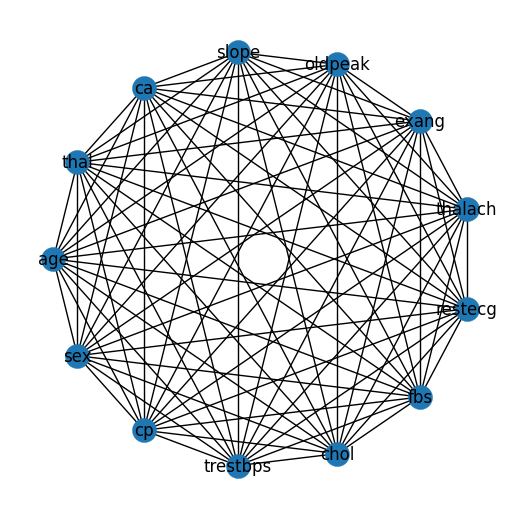

In [92]:
plot_graph(W_new_vac_mst_graph, file_name=None)

In [81]:
# explain the model
W2 = kl_mi_matrix(X, y)
A2, W2_new = create_minimal_edge_graph(W, reverse=True, version='v3')
G2 = nx.Graph(A2)
shapley_value2 = shapley.shapG(G2, m=3, f=classification_kpi, approximate_by_ratio=False)
fig, ax = shapGplot(shapley_value2, top_n=15, show_plot=False)
ax.set_xlabel("Feature importance", fontsize=14)
ax.set_ylabel("Features", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Top 15 influential features', fontsize=16)
plt.show()

NameError: name 'X' is not defined

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, log_loss
from scipy.stats import spearmanr, kendalltau
import networkx as nx

# === your code / modules ===
# from your_project import shapley, matrix_generator_mst, create_minimal_edge_graph_mst
# model_factory is a function that returns a fresh, unfit model (e.g., LightGBM/XGB)

# Define a value function v(S) as a gain (AUCPR or log-loss gain)

In [29]:
def cv_aucpr_gain(model_factory, X, y, features, n_splits=5, random_state=42):
    """Return AUCPR (higher=better). If features=[], return baseline using a constant predictor."""
    if len(features) == 0:
        # baseline: majority-class prior
        p = np.mean(y)
        return p  # AUCPR for random/constant predictor equals positive prevalence

    Xs = X[features].values if isinstance(X, pd.DataFrame) else X[:, features]
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []
    for tr, va in skf.split(Xs, y):
        m = model_factory()
        m.fit(Xs[tr], y[tr])
        proba = m.predict_proba(Xs[va])[:, 1]
        scores.append(average_precision_score(y[va], proba))
    return float(np.mean(scores))

def make_v_gain(model_factory, X, y, feature_names):
    """Closure for ShapG: v(S) expects S as a set/list of features (names or indices)."""
    # allow both names and integer indices:
    name_by_idx = list(feature_names)
    idx_by_name = {n:i for i,n in enumerate(feature_names)}
    def v_fn(S):
        if len(S) == 0:
            return cv_aucpr_gain(model_factory, X, y, [], n_splits=5)
        # normalize S to names:
        if isinstance(S, (list, set, tuple, np.ndarray)):
            S_list = list(S)
        else:
            S_list = [S]
        if isinstance(S_list[0], int):
            feats = [name_by_idx[i] for i in S_list]
        else:
            feats = S_list
        return cv_aucpr_gain(model_factory, X, y, feats, n_splits=5)
    return v_fn


# Compute MST–ShapG importances

In [ ]:
# X: pandas.DataFrame (n x M), y: numpy array shape (n,)
feature_names = list(X.columns)

# Build W and MST graph (your existing functions)
W = matrix_generator_mst(X, spearmanr)  # or your chosen corr function
A, W_new = create_minimal_edge_graph_mst(W, reverse=True, version='mst')  # pure MST
G = nx.Graph(A)

# Value function
v_gain = make_v_gain(model_factory, X, y, feature_names)

# ShapG on MST graph (use stronger sampling + normalization if you want larger, steadier phi)
phi_mst = shapley.shapG(G, m=7, f=v_gain, approximate_by_ratio=True, d_max=1)
# Ensure we have a dict: feature -> value
# If shapG returns an array aligned to columns, adapt:
if not isinstance(phi_mst, dict):
    phi_mst = {f: float(v) for f, v in zip(feature_names, np.asarray(phi_mst))}

NameError: name 'X' is not defined

# Compute SHAP global importances

import shap

# Fit a model on all features for SHAP (same family as v_gain)
m_all = model_factory()
m_all.fit(X.values, y)

# Choose the right explainer for your model type:
explainer = shap.TreeExplainer(m_all)        # for tree models
# explainer = shap.Explainer(m_all, X)       # model-agnostic (slower)

shap_vals = explainer(X)                     # shap.Explanation
# Global importance: mean(|SHAP|) per feature
phi_shap = {f: float(np.mean(np.abs(shap_vals.values[:, i])))
            for i, f in enumerate(feature_names)}

# Normalization helper (efficiency-like)

def normalize_to_gain(phi: dict, v_full: float, v_empty: float):
    gain = v_full - v_empty
    s = sum(phi.values())
    if s == 0:
        return phi.copy()
    return {f: (v * gain / s) for f, v in phi.items()}

v_empty = v_gain([])                         # AUCPR baseline (≈ prevalence)
v_full  = v_gain(feature_names)              # AUCPR with all features

phi_mst_n  = normalize_to_gain(phi_mst,  v_full, v_empty)
phi_shap_n = normalize_to_gain(phi_shap, v_full, v_empty)

# Evaluation toolkit (rank corr, top-k overlap, removal curves)

In [26]:
from scipy.stats import spearmanr, kendalltau
import numpy as np

def rank_correlation(phi_a: dict, phi_b: dict):
    feats = sorted(phi_a.keys())
    a = np.array([phi_a[f] for f in feats])
    b = np.array([phi_b[f] for f in feats])
    # convert to ranks (higher value -> better rank)
    r_a = np.argsort(np.argsort(-a))
    r_b = np.argsort(np.argsort(-b))
    rho, _ = spearmanr(r_a, r_b)
    tau, _ = kendalltau(r_a, r_b)
    return {"spearman": float(rho), "kendall_tau": float(tau)}

def topk_sets(phi: dict, k: int):
    return set(sorted(phi, key=phi.get, reverse=True)[:k])

def topk_overlap(phi_a: dict, phi_b: dict, ks=(5,10,20)):
    out = {}
    for k in ks:
        A, B = topk_sets(phi_a, k), topk_sets(phi_b, k)
        jacc = len(A & B) / len(A | B) if (A|B) else 1.0
        prec = len(A & B) / len(B) if B else 1.0
        rec  = len(A & B) / len(A) if A else 1.0
        out[k] = {"jaccard": jacc, "precision": prec, "recall": rec}
    return out

def removal_curve(v_fn, all_feats, ranking, step=1):
    kept = list(all_feats)
    curve = [(0, v_fn(kept))]
    for r in range(step, len(all_feats)+1, step):
        to_drop = set(ranking[:r])
        kept = [f for f in all_feats if f not in to_drop]
        curve.append((r, v_fn(kept)))
    return curve

def slope_score(curve):
    xs, ys = zip(*curve)
    x = np.array(xs, float)
    y = np.array(ys, float)
    x = x / (x.max() if x.max() > 0 else 1.0)
    y0 = y[0] if y[0] != 0 else 1.0
    y = y / y0
    area = np.trapz(y, x)
    return float(1.0 - area)  # higher => steeper drop => better faithfulness

In [ ]:
all_feats = feature_names

# Rankings (after normalization)
rank_mst  = sorted(phi_mst_n,  key=phi_mst_n.get,  reverse=True)
rank_shap = sorted(phi_shap_n, key=phi_shap_n.get, reverse=True)

# a) Rank correlation
corr = rank_correlation(phi_shap_n, phi_mst_n)

# b) Top-k overlap
overlap = topk_overlap(phi_shap_n, phi_mst_n, ks=(5,10,20))

# c) Removal curves + slope score (faithfulness)
step = max(1, len(all_feats)//20)
curve_mst  = removal_curve(v_gain, all_feats, rank_mst,  step=step)
curve_shap = removal_curve(v_gain, all_feats, rank_shap, step=step)
S_mst  = slope_score(curve_mst)
S_shap = slope_score(curve_shap)

print("Rank correlation:", corr)
print("Top-k overlap:", overlap)
print("Slope score — MST vs. SHAP:", S_mst, S_shap)


# Eval

In [97]:
# ==== Fig.8/9-style visualization: R² vs number of removed features ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.dummy import DummyRegressor
import lightgbm as lgb

def cv_r2_with_features(X_df: pd.DataFrame,
                        y: np.ndarray,
                        feat_list: list,
                        n_splits: int = 5,
                        random_state: int = 42,
                        lgb_params: dict = None) -> float:
    """
    Train/evaluate LightGBM on ONLY the columns in feat_list using K-Fold CV and return mean R².
    If feat_list is empty, return baseline R² using a DummyRegressor (predict mean).
    """
    if lgb_params is None:
        lgb_params = dict(learning_rate=0.2, verbosity=-1)

    if len(feat_list) == 0:
        # Baseline: predict mean of y in each train fold
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        preds, trues = [], []
        z = np.zeros((len(X_df), 1))  # dummy single feature (ignored by DummyRegressor)
        for tr, va in kf.split(z):
            y_tr, y_va = y[tr], y[va]
            d = DummyRegressor(strategy="mean").fit(z[tr], y_tr)
            p = d.predict(z[va])
            preds.append(p); trues.append(y_va)
        preds = np.concatenate(preds); trues = np.concatenate(trues)
        return float(r2_score(trues, preds))

    Xs = X_df[feat_list].values
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    preds, trues = [], []
    for tr, va in kf.split(Xs):
        m = lgb.LGBMRegressor(**lgb_params)
        m.fit(Xs[tr], y[tr])
        p = m.predict(Xs[va])
        preds.append(p); trues.append(y[va])
    preds = np.concatenate(preds); trues = np.concatenate(trues)
    return float(r2_score(trues, preds))


def build_removal_curve_r2(X_df: pd.DataFrame,
                           y: np.ndarray,
                           ranking: list,
                           step: int = 1,
                           n_splits: int = 5,
                           random_state: int = 42,
                           lgb_params: dict = None):
    """
    Given a ranking (most -> least important), drop features progressively and compute R².
    Returns a list of (num_removed, R²).
    """
    all_feats = list(X_df.columns)
    # Ensure supplied ranking covers only known columns and keeps order
    ranking = [f for f in ranking if f in all_feats]

    # Start with all features kept
    kept = list(all_feats)
    curve = []

    # R² with all features (0 removed)
    r2_full = cv_r2_with_features(X_df, y, kept,
                                  n_splits=n_splits,
                                  random_state=random_state,
                                  lgb_params=lgb_params)
    curve.append((0, r2_full))

    # Drop features chunk-by-chunk
    for r in range(step, len(ranking) + 1, step):
        to_drop = set(ranking[:r])
        kept = [f for f in all_feats if f not in to_drop]
        r2_now = cv_r2_with_features(X_df, y, kept,
                                     n_splits=n_splits,
                                     random_state=random_state,
                                     lgb_params=lgb_params)
        curve.append((r, r2_now))

    # Ensure last point: all features removed
    if curve[-1][0] != len(all_feats):
        r2_empty = cv_r2_with_features(X_df, y, [],
                                       n_splits=n_splits,
                                       random_state=random_state,
                                       lgb_params=lgb_params)
        curve.append((len(all_feats), r2_empty))

    return curve


def plot_removal_curves(curves_dict: dict,
                        title: str = "R² vs #Features Removed",
                        xlabel: str = "# features removed",
                        ylabel: str = "R²"):
    """
    curves_dict: {"Name": [(num_removed, r2), ...], ...}
    """
    plt.figure(figsize=(8, 5))
    for name, curve in curves_dict.items():
        xs, ys = zip(*curve)
        plt.plot(xs, ys, marker='o', linewidth=2, label=name)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================
# ====== HOW TO USE IT =======
# ============================

# 0) Prepare your data
# X: pandas DataFrame, y: numpy array
# X, y = h1n1_data_reader('./data/process_data.csv')  # your loader should return X as DataFrame

# 1) Prepare rankings (lists from most -> least important).
#    If you already have dicts phi_mst / phi_shap (feature -> importance), do:
# rank_mst  = sorted(phi_mst,  key=phi_mst.get,  reverse=True)
# rank_shap = sorted(phi_shap, key=phi_shap.get, reverse=True)

#    If you have SHAP Explanation 'shap_values' already (like in your snippet):
# import numpy as np
# vals = np.mean(np.abs(shap_values.values), axis=0)  # (n_samples, n_features) -> (n_features,)
# phi_shap = dict(zip(X.columns, vals))
# rank_shap = sorted(phi_shap, key=phi_shap.get, reverse=True)

#    If your ShapG output is an array aligned to X.columns:
# import numpy as np
# vals_mst = np.asarray(shapley_value_vac_mst).reshape(-1)
# phi_mst = dict(zip(X.columns, vals_mst))
# rank_mst = sorted(phi_mst, key=phi_mst.get, reverse=True)

# 2) Build curves (use step=1 for exact Fig.8/9; step=2 is faster)
# curve_mst  = build_removal_curve_r2(X, y, rank_mst,  step=1, n_splits=5, random_state=42)
# curve_shap = build_removal_curve_r2(X, y, rank_shap, step=1, n_splits=5, random_state=42)

# 3) Plot like the paper
# plot_removal_curves({"ShapG+MST": curve_mst, "SHAP": curve_shap},
#                     title="R² vs #Features Removed (drop order by explainer)")


In [99]:
import numpy as np
vals = np.mean(np.abs(shap_values.values), axis=0)  # (n_samples, n_features) -> (n_features,)
phi_shap = dict(zip(X_vac_shap.columns, vals))
rank_shap = sorted(phi_shap, key=phi_shap.get, reverse=True)

In [100]:
import numpy as np
vals_mst = np.asarray(shapley_value_vac_mst).reshape(-1)
phi_mst = dict(zip(X_vac_mst.columns, vals_mst))
rank_mst = sorted(phi_mst, key=phi_mst.get, reverse=True)

In [106]:
def to_phi_dict(shapg_out, feature_names):
    """
    Convert various ShapG outputs into {feature_name: float_value}.
    Handles:
      - dict already keyed by feature names or indices
      - list/array of numbers
      - list/array of dicts with keys like ('feature'|'name'|'node'|index) and ('value'|'phi'|'score'|'importance'|'shapley')
      - dict with parallel lists: {'features': [...], 'values': [...]}
    """
    import numpy as np

    feats = list(feature_names)

    # Case 1: Already a dict
    if isinstance(shapg_out, dict):
        keys = list(shapg_out.keys())
        # dict keyed by feature names
        if all(k in feats for k in keys):
            return {k: float(shapg_out[k]) for k in keys}
        # dict keyed by indices (int or str int)
        try:
            idx_keys = [int(k) for k in keys]
            if all(0 <= i < len(feats) for i in idx_keys):
                return {feats[int(k)]: float(shapg_out[k]) for k in keys}
        except Exception:
            pass
        # dict with parallel lists?
        for fk in ('features','feature_names','nodes','cols'):
            for vk in ('values','phi','scores','importances','shapley'):
                if fk in shapg_out and vk in shapg_out:
                    f_list, v_list = list(shapg_out[fk]), list(shapg_out[vk])
                    return { (f if f in feats else feats[int(f)]): float(v)
                             for f, v in zip(f_list, v_list) }
        raise TypeError("Unrecognized dict format from ShapG output")

    # Convert to list for other cases
    arr = shapg_out
    if isinstance(arr, np.ndarray):
        arr = arr.tolist()

    # Case 2: list/array of numbers (aligned to columns)
    if isinstance(arr, (list, tuple)) and len(arr) == len(feats) and all(
        (isinstance(x, (int, float)) or (isinstance(x, np.generic)))
        for x in arr
    ):
        return {f: float(v) for f, v in zip(feats, arr)}

    # Case 3: list/array of dicts (common)
    if isinstance(arr, (list, tuple)) and len(arr) == len(feats) and all(isinstance(x, dict) for x in arr):
        # Find keys
        feature_keys = ('feature','name','node','col','feat','index','idx','id')
        value_keys   = ('value','phi','score','importance','shapley','val')
        out = {}
        for i, item in enumerate(arr):
            # feature id
            fk = next((k for k in feature_keys if k in item), None)
            if fk is not None:
                f = item[fk]
                # if index given
                if isinstance(f, (int, np.integer)) and 0 <= f < len(feats):
                    fname = feats[int(f)]
                else:
                    # assume name string
                    fname = str(f)
            else:
                # fallback to position i
                fname = feats[i]

            # value
            vk = next((k for k in value_keys if k in item), None)
            if vk is None:
                raise TypeError(f"Missing value key in ShapG item {i}: {item}")
            out[fname] = float(item[vk])
        return out

    # Case 4: list of (feature, value) pairs
    if isinstance(arr, (list, tuple)) and all(isinstance(x, (list, tuple)) and len(x) == 2 for x in arr):
        out = {}
        for f, v in arr:
            fname = feats[int(f)] if isinstance(f, int) and 0 <= f < len(feats) else str(f)
            out[fname] = float(v)
        return out

    raise TypeError("Could not coerce ShapG output to {feature: value}. Inspect structure and adjust keys.")


/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/l

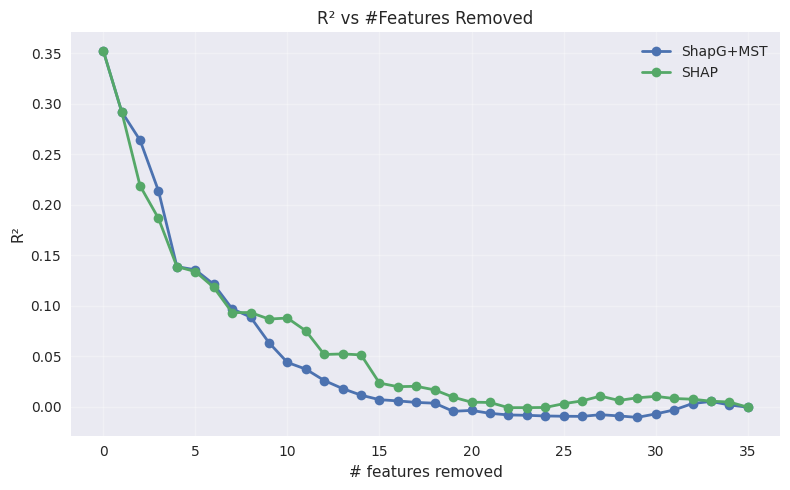

In [107]:
# Build phi_mst robustly
phi_mst = to_phi_dict(shapley_value_vac_mst, X_vac_mst.columns)
rank_mst = sorted(phi_mst, key=phi_mst.get, reverse=True)

# Build phi_shap (global) from your SHAP explanation
import numpy as np
vals_shap = np.mean(np.abs(shap_values.values), axis=0)  # shape: (n_features,)
phi_shap  = {f: float(v) for f, v in zip(X_vac_shap.columns, vals_shap)}
rank_shap = sorted(phi_shap, key=phi_shap.get, reverse=True)

# Now rebuild the R² removal curves with your existing plotting code
curve_mst  = build_removal_curve_r2(X_vac_mst, y_vac_mst, rank_mst,  step=1)
curve_shap = build_removal_curve_r2(X_vac_mst, y_vac_mst, rank_shap, step=1)
plot_removal_curves({"ShapG+MST": curve_mst, "SHAP": curve_shap})

In [105]:
# Build phi_mst correctly from the ShapG array (aligned to X_vac_mst.columns)
import numpy as np
vals_mst = np.asarray(shapley_value_vac_mst).reshape(-1)
phi_mst = {f: float(v) for f, v in zip(X_vac_mst.columns, vals_mst)}
rank_mst = sorted(phi_mst, key=phi_mst.get, reverse=True)

# Do the same for SHAP (mean |shap| per feature):
import numpy as np
vals_shap = np.mean(np.abs(shap_values.values), axis=0)
phi_shap  = {f: float(v) for f, v in zip(X_vac_shap.columns, vals_shap)}
rank_shap = sorted(phi_shap, key=phi_shap.get, reverse=True)


TypeError: float() argument must be a string or a number, not 'dict'

In [102]:
curve_mst  = build_removal_curve_r2(X_vac_shap, y_vac_shap, rank_mst,  step=1, n_splits=5, random_state=42)
curve_shap = build_removal_curve_r2(X_vac_mst, y_vac_mst, rank_shap, step=1, n_splits=5, random_state=42)

/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/khoim/.local/l

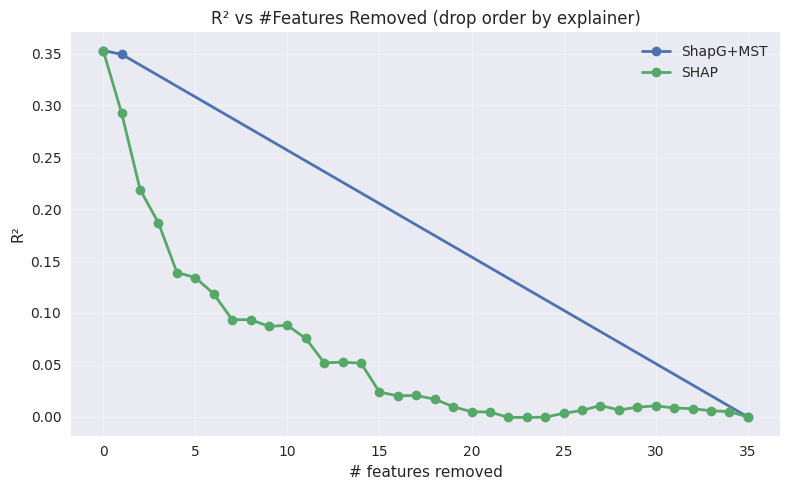

In [103]:
plot_removal_curves({"ShapG+MST": curve_mst, "SHAP": curve_shap},
                    title="R² vs #Features Removed (drop order by explainer)")

In [ ]:
# ===== ShapG+MST vs SHAP, Accuracy-based drop curves (Fig.8/9 style) =====
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- import the authors' benchmark helpers you shared ---
# Make sure benchmark_feature_importance.py is on PYTHONPATH or same folder.
from benchmark_feature_importance import (
    h1n1_data_reader,
    plot_KPI_comparison_by_dict,   # we will use this one
)

# --- your MST graph builders (update import path to your project) ---
# from mst import matrix_generator_mst, create_minimal_edge_graph_mst
# If these live elsewhere, adjust the import accordingly.

# ------- 1) Load data (classification) -------
X, y = h1n1_data_reader('./data/process_data.csv')   # returns DataFrame X, Series/array y

# ------- 2) Build correlation matrix & MST graph -------
# Use Spearman (good for monotonic non-linear relations)
from scipy.stats import spearmanr
from shapG.mst import matrix_generator_mst, create_minimal_edge_graph_mst

W = matrix_generator_mst(X, method=spearmanr)
A, W_new = create_minimal_edge_graph_mst(W, version='mst', verbose=True)
G = nx.Graph(A)

# ------- 3) Define value function for ShapG: classification accuracy -------
# This mirrors the paper’s Section 5 idea: performance metric = Accuracy
def classification_accuracy_gain(S):
    cols = list(S)
    if len(cols) == 0:
        return 0.0
    x_train, x_test, y_train, y_test = train_test_split(
        X[cols], y, test_size=0.2, random_state=42, stratify=y
    )
    clf = lgb.LGBMClassifier(learning_rate=0.2, verbosity=-1)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    return float(accuracy_score(y_test, y_pred))

# Some versions of shapG expect f(S); others expect f(G, S). Provide both lambdas:
def f_only_S(S):      return classification_accuracy_gain(S)
def f_with_G(Gin, S): return classification_accuracy_gain(S)

# ------- 4) Run ShapG on MST graph (accuracy-based) -------
from shapG.shapley import shapG as shapG_local  # or from your module path
try:
    # API variant f(S)
    shapg_out = shapG_local(G, m=7, f=f_only_S, approximate_by_ratio=True)
except TypeError:
    # API variant f(G,S)
    shapg_out = shapG_local(G, m=7, f=f_with_G, approximate_by_ratio=True)

# Robust adapter: turn shapG output into {feature: score}
def to_phi_dict(shapg_output, feature_names):
    feats = list(feature_names)
    if isinstance(shapg_output, dict):
        # already a dict keyed by names or indices
        try:
            if all(k in feats for k in shapg_output.keys()):
                return {k: float(v) for k, v in shapg_output.items()}
            idx_keys = [int(k) for k in shapg_output.keys()]
            if all(0 <= i < len(feats) for i in idx_keys):
                return {feats[int(k)]: float(shapg_output[k]) for k in shapg_output}
        except Exception:
            pass
    # list/array aligned to columns
    arr = np.asarray(shapg_output).reshape(-1)
    assert len(arr) == len(feats), "ShapG output length != #features"
    return {f: float(v) for f, v in zip(feats, arr)}

phi_mst = to_phi_dict(shapg_out, X.columns)
rank_mst = sorted(phi_mst, key=phi_mst.get, reverse=True)

# ------- 5) SHAP global ranking (accuracy task, same classifier) -------
clf_all = lgb.LGBMClassifier(learning_rate=0.2, verbosity=-1).fit(X, y)
# TreeExplainer is fastest for tree models
explainer = shap.TreeExplainer(clf_all)
shap_values = explainer(X)                     # shap.Explanation
shap_global = np.mean(np.abs(shap_values.values), axis=0)  # (n_features,)
phi_shap = {f: float(v) for f, v in zip(X.columns, shap_global)}
rank_shap = sorted(phi_shap, key=phi_shap.get, reverse=True)

# ------- 6) Feed both rankings to the authors' plotting function -------
feature_rankings = {
    "ShapG+MST": rank_mst,   # list of feature names, most->least important
    "SHAP":      rank_shap,
}

# IMPORTANT: use a classifier model here so the benchmark plots Accuracy,
# see their code path (it switches metric by model type).
model_for_benchmark = lgb.LGBMClassifier(learning_rate=0.2, verbosity=-1)

# limit: how many top features to drop sequentially (paper shows small K like 7–15;
# set None to drop across full ranking)
results = plot_KPI_comparison_by_dict(
    reader=lambda: (X, y),                   # reuse current X,y
    feature_rankings=feature_rankings,
    model=model_for_benchmark,
    filename="accuracy_benchmark.png",       # saved figure
    limit=None                               # or an int, e.g., 15
)

print("Weighted slope S (alpha=0.8) per method:", {k: v["Slope"] for k,v in results.items()})
print("Figure saved to: accuracy_benchmark.png")

[mst] edges selected: 34


TypeError: shapG() got an unexpected keyword argument 'd_max'